In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qubo_utils import *

Solver Utility Functions

In [11]:
import itertools
import numpy as np


def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


def brute_force(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    valid_results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        if check_validity(bits, edges, nodes, targets):

            path_cost = sum(
                costs[i]
                for i in range(len(edges))
                if bits[i] == 1
            )

            valid_results.append({
                "bits": bits,
                "energy": energy,
                "path_cost": path_cost
            })

    best = min(valid_results, key=lambda r: r["energy"])

    return best

In [12]:
import matplotlib.pyplot as plt
import itertools
import numpy as np


def make_plot(Q, costs, edges, nodes, targets):
    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        valid = check_validity(bits, edges, nodes, targets)

        path_cost = sum(
            costs[i]
            for i in range(len(edges))
            if bits[i] == 1
        )

        results.append({
            "energy": energy,
            "valid": valid,
            "path_cost": path_cost
        })

    valid_results = [r for r in results if r["valid"]]
    best = min(valid_results, key=lambda r: r["energy"])

    x_vals = [r["path_cost"] for r in results]
    y_vals = [r["energy"] for r in results]
    colors = ["green" if r["valid"] else "red" for r in results]

    plt.figure(figsize=(10,6))
    plt.scatter(x_vals, y_vals, c=colors, s=20)

    plt.title("Energy vs Path Cost")
    plt.xlabel("Path Cost")
    plt.ylabel("Energy")
    plt.grid(True, alpha=0.3)
    plt.axhline(best["energy"], linestyle="--", label="Min Valid Energy")
    plt.legend()
    plt.show()

In [13]:
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
costs = [2.5, 5.0, 1.0, 3.0, 1.5]
nodes = [0,1,2,3]
targets = {0:1, 1:0, 2:0, 3:-1}

Q = build_Q(costs, edges, nodes, targets)
print(Q)

[[ 22.5  40.    0.    0.    0.  -80.    0. ]
 [  0.   25.   80.    0.    0.    0.  -80. ]
 [  0.    0.   81.   80.    0.  -80.  -80. ]
 [  0.    0.    0.   23.   40.  -80.    0. ]
 [  0.    0.    0.    0.   21.5   0.  -80. ]
 [  0.    0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.    0.    0.    0.   80. ]]


--- VALIDATION RESULTS ---
Lowest VALID Energy: -35.0
Best Configuration: (1, 0, 1, 0, 1, 1, 1)
Human Readable Path: AB -> BC -> CD
Path Length: 5.0


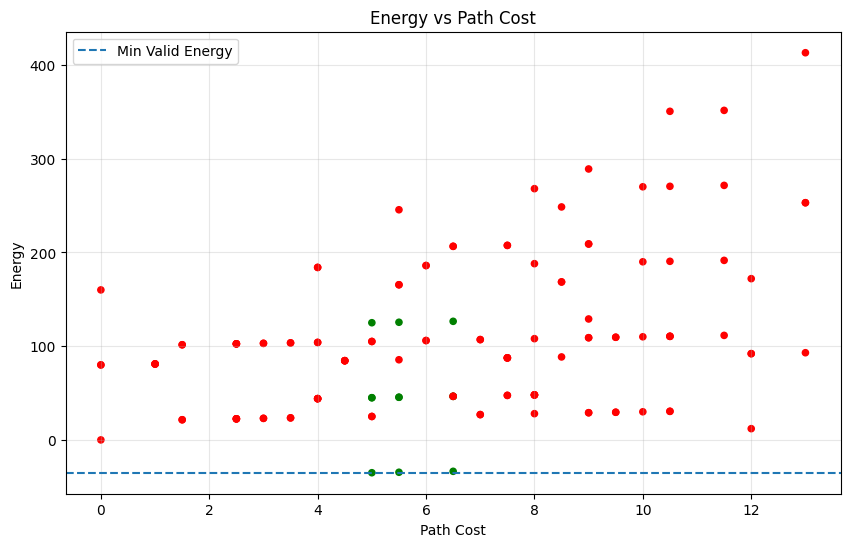

In [14]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

# --- SETUP GRAPH ---
edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
edge_names = ["AB", "AC", "BC", "BD", "CD"]

costs = [2.5, 5.0, 1.0, 3.0, 1.5]

nodes = [0,1,2,3]

targets = {0:1, 1:0, 2:0, 3:-1}

# Build QUBO
Q = build_Q(costs, edges, nodes, targets)

# Solve
best = brute_force(Q, costs, edges, nodes, targets)

# Output
print("--- VALIDATION RESULTS ---")
print("Lowest VALID Energy:", best["energy"])
print("Best Configuration:", best["bits"])
print("Human Readable Path:", get_path_string(best["bits"], edge_names))
print("Path Length:", best["path_cost"])

make_plot(Q, costs, edges, nodes, targets)


In [15]:
import random

def classical_shortest_path(costs):
    candidates = [
        costs[0] + costs[3],                 # AB -> BD
        costs[1] + costs[4],                 # AC -> CD
        costs[0] + costs[2] + costs[4]      # AB -> BC -> CD
    ]
    return min(candidates)


def test_run():
    edges = [(0,1), (0,2), (1,2), (1,3), (2,3)]
    edge_names = ["AB","AC","BC","BD","CD"]
    nodes = [0,1,2,3]
    targets = {0:1,1:0,2:0,3:-1}

    costs = [random.randint(1,9) for _ in range(5)]

    Q = build_Q(costs, edges, nodes, targets)

    best = brute_force(Q, costs, edges, nodes, targets)

    qubo_cost = best["path_cost"]
    classical_cost = classical_shortest_path(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print("Costs:", costs)
    print("QUBO Cost:", qubo_cost)
    print("Classical Cost:", classical_cost)
    print("Result:", status)

## Larger Graph Test (5 Nodes)
Testing generalized build_Q() on a bigger graph.

In [16]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(10, 10)
[[ 22.  40.   0.   0.   0.   0.   0. -80.   0.   0.]
 [  0.  24.  80.   0.   0.   0.   0.   0. -80.   0.]
 [  0.   0.  81.  80.   0.   0.   0. -80. -80.   0.]
 [  0.   0.   0.  83.  80.   0.   0. -80.   0. -80.]
 [  0.   0.   0.   0.  82.  80.   0.   0. -80. -80.]
 [  0.   0.   0.   0.   0.  25.  40.   0. -80.   0.]
 [  0.   0.   0.   0.   0.   0.  21.   0.   0. -80.]
 [  0.   0.   0.   0.   0.   0.   0.  80.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  80.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.  80.]]


Verify solver still finds correct shortest valid path on larger graph.

In [17]:
import itertools
import numpy as np

num_vars = Q.shape[0]

def check_validity(bits, edges, nodes, targets):
    active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

    if not active_edges:
        return False

    for v in nodes:
        in_degree = sum(1 for u, w in active_edges if w == v)
        out_degree = sum(1 for u, w in active_edges if u == v)

        if (out_degree - in_degree) != targets[v]:
            return False

    return True


def get_path_string(bits, edge_names):
    chosen = [
        edge_names[i]
        for i in range(len(edge_names))
        if bits[i] == 1
    ]
    return " -> ".join(chosen) if chosen else "No Path"


results = []

for bits in itertools.product([0,1], repeat=num_vars):
    x = np.array(bits)

    energy = x.T @ Q @ x
    valid = check_validity(bits, edges, nodes, targets)

    path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)

    results.append((bits, energy, valid, path_cost))

valid_results = [r for r in results if r[2]]

best = min(valid_results, key=lambda x: x[1])

print("Lowest VALID Energy:", best[1])
print("Best Configuration:", best[0])
print("Chosen Path:", get_path_string(best[0], edge_names))
print("Path Cost:", best[3])

Lowest VALID Energy: -34.0
Best Configuration: (1, 0, 0, 1, 0, 0, 1, 1, 0, 1)
Chosen Path: 01 -> 13 -> 34
Path Cost: 6


Batch Validation with Random Edge Weights

In [18]:
import random
import itertools
import numpy as np

# fixed graph structure
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]
nodes = [0,1,2,3,4]

targets = {0:1, 1:0, 2:0, 3:0, 4:-1}


def classical_paths(costs):
    candidates = {
        "01->13->34": costs[0] + costs[3] + costs[6],
        "02->24": costs[1] + costs[5],
        "01->12->24": costs[0] + costs[2] + costs[5],
        "01->12->23->34": costs[0] + costs[2] + costs[4] + costs[6],
        "02->23->34": costs[1] + costs[4] + costs[6],
    }
    return min(candidates.values())


for test in range(10):

    costs = [random.randint(1,9) for _ in range(len(edges))]

    Q = build_Q(costs, edges, nodes, targets)

    num_vars = Q.shape[0]

    results = []

    for bits in itertools.product([0,1], repeat=num_vars):
        x = np.array(bits)

        energy = x.T @ Q @ x

        active_edges = [edges[i] for i in range(len(edges)) if bits[i] == 1]

        valid = True
        if not active_edges:
            valid = False

        for v in nodes:
            indeg = sum(1 for u,w in active_edges if w == v)
            outdeg = sum(1 for u,w in active_edges if u == v)

            if outdeg - indeg != targets[v]:
                valid = False

        if valid:
            path_cost = sum(costs[i] for i in range(len(edges)) if bits[i] == 1)
            results.append((energy, path_cost))

    best = min(results, key=lambda x: x[0])

    qubo_cost = best[1]
    classical_cost = classical_paths(costs)

    status = "PASS" if qubo_cost == classical_cost else "FAIL"

    print(f"Test {test+1}: costs={costs} | QUBO={qubo_cost} | Classical={classical_cost} --> {status}")

Test 1: costs=[8, 1, 1, 3, 3, 4, 4] | QUBO=5 | Classical=5 --> PASS
Test 2: costs=[6, 1, 8, 8, 8, 6, 7] | QUBO=7 | Classical=7 --> PASS
Test 3: costs=[9, 7, 7, 4, 2, 1, 8] | QUBO=8 | Classical=8 --> PASS
Test 4: costs=[8, 2, 1, 4, 2, 2, 3] | QUBO=4 | Classical=4 --> PASS
Test 5: costs=[4, 5, 3, 1, 4, 4, 5] | QUBO=9 | Classical=9 --> PASS
Test 6: costs=[7, 7, 4, 7, 2, 2, 4] | QUBO=9 | Classical=9 --> PASS
Test 7: costs=[7, 4, 2, 7, 4, 6, 6] | QUBO=10 | Classical=10 --> PASS
Test 8: costs=[9, 4, 3, 7, 8, 9, 8] | QUBO=13 | Classical=13 --> PASS
Test 9: costs=[9, 8, 4, 9, 3, 1, 4] | QUBO=9 | Classical=9 --> PASS
Test 10: costs=[1, 4, 4, 3, 1, 9, 6] | QUBO=10 | Classical=10 --> PASS


Two Simultaneous Paths Prototype

In [19]:
Q_single = build_Q(costs, edges, nodes, targets)

n = Q_single.shape[0]
m = len(edges)          # number of real edge variables only

Q_two = np.zeros((2*n, 2*n))

# route 1 block
Q_two[:n, :n] = Q_single

# route 2 block
Q_two[n:, n:] = Q_single

# shared-edge penalty
Pc = 50

for e in range(m):
    Q_two[e, n + e] += Pc

print(Q_two.shape)
print(Q_two)

(20, 20)
[[ 21.  40.   0.   0.   0.   0.   0. -80.   0.   0.  50.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.  24.  80.   0.   0.   0.   0.   0. -80.   0.   0.  50.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.  84.  80.   0.   0.   0. -80. -80.   0.   0.   0.  50.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.  83.  80.   0.   0. -80.   0. -80.   0.   0.   0.  50.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.  81.  80.   0.   0. -80. -80.   0.   0.   0.   0.
   50.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.  29.  40.   0. -80.   0.   0.   0.   0.   0.
    0.  50.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.  26.   0.   0. -80.   0.   0.   0.   0.
    0.   0.  50.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.  80.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  80.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.

In [20]:
print("Populated QUBO Matrix Q:\n", Q)

Populated QUBO Matrix Q:
 [[ 21.  40.   0.   0.   0.   0.   0. -80.   0.   0.]
 [  0.  24.  80.   0.   0.   0.   0.   0. -80.   0.]
 [  0.   0.  84.  80.   0.   0.   0. -80. -80.   0.]
 [  0.   0.   0.  83.  80.   0.   0. -80.   0. -80.]
 [  0.   0.   0.   0.  81.  80.   0.   0. -80. -80.]
 [  0.   0.   0.   0.   0.  29.  40.   0. -80.   0.]
 [  0.   0.   0.   0.   0.   0.  26.   0.   0. -80.]
 [  0.   0.   0.   0.   0.   0.   0.  80.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  80.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.  80.]]


In [21]:
import random

print("Running robustness test with random edge costs...\n")

for i in range(5):
    random_costs = [round(random.uniform(1, 10), 1) for _ in range(5)]

    shortest_path = min(random_costs[0] + random_costs[3],   # AB + BD
                        random_costs[1] + random_costs[4],   # AC + CD
                        random_costs[0] + random_costs[2] + random_costs[4]) # AB+BC+CD

    print(f"Test {i+1}: Costs = {random_costs}")
    print(f"Expected shortest path length = {shortest_path}")
    print("-" * 40) 

Running robustness test with random edge costs...

Test 1: Costs = [5.8, 6.4, 5.8, 2.7, 8.2]
Expected shortest path length = 8.5
----------------------------------------
Test 2: Costs = [2.3, 2.6, 4.7, 8.9, 9.2]
Expected shortest path length = 11.2
----------------------------------------
Test 3: Costs = [8.3, 3.1, 4.4, 3.4, 3.6]
Expected shortest path length = 6.7
----------------------------------------
Test 4: Costs = [4.2, 2.5, 3.3, 9.6, 4.8]
Expected shortest path length = 7.3
----------------------------------------
Test 5: Costs = [8.1, 2.0, 7.7, 9.7, 2.2]
Expected shortest path length = 4.2
----------------------------------------


Below we are using different random weights 

In [22]:
import numpy as np
import itertools
import random

def run_stress_test_with_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        
        # 2. Re-build the Q Matrix from scratch for these weights
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                for j, s_vj in conn:
                    if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj

        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_with_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: VALID | Path: AB -> BD | Energy: -30.3 | Weights: [4.07, 3.92, 4.67, 5.6, 7.47]
Run 2: VALID | Path: AB -> BD | Energy: -30.4 | Weights: [5.42, 9.97, 7.18, 4.18, 7.95]
Run 3: VALID | Path: AB -> BD | Energy: -28.8 | Weights: [8.34, 2.62, 1.28, 2.88, 8.69]
Run 4: VALID | Path: AC -> CD | Energy: -27.9 | Weights: [8.65, 5.95, 2.02, 6.59, 6.19]
Run 5: VALID | Path: AC -> CD | Energy: -27.4 | Weights: [8.93, 7.72, 7.23, 9.41, 4.84]
Run 6: VALID | Path: AB -> BD | Energy: -29.6 | Weights: [4.1, 3.67, 4.59, 6.28, 9.55]
Run 7: VALID | Path: AB -> BD | Energy: -35.6 | Weights: [1.99, 3.51, 9.62, 2.41, 6.58]
Run 8: VALID | Path: AC -> CD | Energy: -30.5 | Weights: [9.51, 5.33, 1.04, 6.83, 4.21]
Run 9: VALID | Path: AB -> BD | Energy: -29.8 | Weights: [1.23, 7.35, 2.35, 8.94, 8.23]
Run 10: VALID | Path: AC -> CD | Energy: -29.8 | Weights: [3.07, 5.55, 4.72, 7.34, 4.6]

--- TEST COMPLETE ---
Final Reliability: 100.0%


Accordiing to the results we got above it proves that even though the weights chaged every single time it always found a valid path

In the code below we have removed the flow term ( That part is commented out) and ran the code with 5 random values for edges.

In [23]:
import numpy as np
import itertools
import random

def run_stress_test_without_flow(iterations=10):
    # Graph Definition
    edges = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] # AB, AC, BC, BD, CD
    edge_names = ["AB", "AC", "BC", "BD", "CD"]
    nodes = [0, 1, 2, 3] # A, B, C, D
    targets = {0: 1, 3: -1, 1: 0, 2: 0} # A=Source, D=Sink
    num_vars = 7
    P1, P2 = 20, 20 # Penalty weights

    success_count = 0

    print(f"--- STARTING STRESS TEST ({iterations} iterations) ---")

    for run_idx in range(iterations):
        # 1. Generate Random Weights for this specific run
        test_costs = [round(random.uniform(1.0, 10.0), 2) for _ in range(5)]
        Q_test = np.zeros((num_vars, num_vars))

        # Add Edge Costs to Diagonal
        for i in range(len(test_costs)):
            Q_test[i, i] += test_costs[i]

        # Add P1 (Flow Conservation)
        """ 
        for v in nodes:
            conn = []
            for i, (u, w) in enumerate(edges):
                if u == v: conn.append((i, 1))
                elif w == v: conn.append((i, -1))
            
            Tv = targets[v]
            for i, s_vi in conn:
                #Q_test[i, i] += P1 * (1 - 2 * Tv * s_vi)
                #for j, s_vj in conn:
                    #if i < j: Q_test[i, j] += 2 * P1 * s_vi * s_vj
        """
        # Add P2 (Intermediate Node Degree)
        for v in [1, 2]: # Nodes B and C
            y_idx = 5 if v == 1 else 6
            conn = [i for i, (u, w) in enumerate(edges) if u == v or w == v]
            for i in conn:
                Q_test[i, i] += P2
                for j in conn:
                    if i < j: Q_test[i, j] += 2 * P2
            for i in conn:
                Q_test[i, y_idx] -= 4 * P2
            Q_test[y_idx, y_idx] += 4 * P2

        # 3. Solve via Brute Force
        current_results = []
        for bits in itertools.product([0, 1], repeat=num_vars):
            x = np.array(bits)
            energy = x.T @ Q_test @ x
            
            # Internal check_validity logic
            active_edges = [edges[i] for i in range(5) if bits[i] == 1]
            is_valid = True
            if not active_edges:
                is_valid = False
            else:
                for v in nodes:
                    in_deg = sum(1 for u, w in active_edges if w == v)
                    out_deg = sum(1 for u, w in active_edges if u == v)
                    if (out_deg - in_deg) != targets[v]:
                        is_valid = False
                        break
            
            current_results.append({'bits': bits, 'energy': energy, 'valid': is_valid})

        # 4. Find the absolute minimum
        current_results.sort(key=lambda x: x['energy'])
        best_found = current_results[0]
        
        # Determine Path String
        path_str = " -> ".join([edge_names[i] for i in range(5) if best_found['bits'][i] == 1])

        if best_found['valid']:
            success_count += 1
            print(f"Run {run_idx+1}: VALID | Path: {path_str} | Energy: {best_found['energy']:.1f} | Weights: {test_costs}")
        else:
            print(f"Run {run_idx+1}: INVALID | Weights: {test_costs}")

    print(f"\n--- TEST COMPLETE ---")
    print(f"Final Reliability: {(success_count/iterations)*100}%")

# Execute the test
run_stress_test_without_flow(10)

--- STARTING STRESS TEST (10 iterations) ---
Run 1: INVALID | Weights: [7.07, 1.07, 8.66, 4.46, 7.02]
Run 2: INVALID | Weights: [2.65, 2.86, 1.87, 3.71, 2.26]
Run 3: INVALID | Weights: [2.86, 7.51, 4.22, 6.07, 4.33]
Run 4: INVALID | Weights: [4.44, 4.41, 1.28, 9.71, 9.61]
Run 5: INVALID | Weights: [1.13, 4.78, 7.21, 6.8, 6.56]
Run 6: INVALID | Weights: [2.89, 3.97, 8.53, 9.15, 9.68]
Run 7: INVALID | Weights: [7.64, 8.09, 6.83, 7.17, 3.74]
Run 8: INVALID | Weights: [8.89, 9.43, 6.72, 4.69, 8.41]
Run 9: INVALID | Weights: [4.56, 9.49, 2.57, 5.51, 3.03]
Run 10: INVALID | Weights: [4.72, 1.58, 2.58, 1.79, 5.22]

--- TEST COMPLETE ---
Final Reliability: 0.0%


So according to the results we got above it shows that without the flow term the program picks NO edges because that gives the lowest energy. Selecting a valid path costs some energy, so program chooses an invalid path that gives 0 energy which is always selecting no edge at all (0,0,0,0,0,0,0).And our validity checker gives always answer as "invalid" because it violates our requirements 

When the flow term is available ;If A acts as a source (+1 flow) and D acts as a sink (-1 flow), that penalty becomes 0.And if Node A doesn't have an outgoing edge and Node D doesn't have an incoming edge ,energy gets increased by 20.



In [24]:
test_run()

Costs: [9, 2, 9, 8, 5]
QUBO Cost: 7
Classical Cost: 7
Result: PASS


Multipath Prototype

In [25]:
# Two required source-target pairs
path_targets = [(0,3), (1,4)]

print("Required Paths:")
for i, (s, t) in enumerate(path_targets, 1):
    print(f"Path {i}: {s} -> {t}")

Required Paths:
Path 1: 0 -> 3
Path 2: 1 -> 4


In [26]:
# Example graph with 6 edges
edges = [(0,1), (0,2), (1,3), (2,3), (1,4), (2,4)]

num_edges = len(edges)
num_paths = len(path_targets)

# one binary block per path
total_variables = num_edges * num_paths

print("Edges:", edges)
print("Edges per path:", num_edges)
print("Number of paths:", num_paths)
print("Total binary variables:", total_variables)

Edges: [(0, 1), (0, 2), (1, 3), (2, 3), (1, 4), (2, 4)]
Edges per path: 6
Number of paths: 2
Total binary variables: 12


In [27]:
print("Variable Index Map")

for p in range(num_paths):
    print(f"\nPath {p+1} variables:")

    for e in range(num_edges):
        var_index = p * num_edges + e
        print(f"x[{var_index}] = Path {p+1}, Edge {edges[e]}")

Variable Index Map

Path 1 variables:
x[0] = Path 1, Edge (0, 1)
x[1] = Path 1, Edge (0, 2)
x[2] = Path 1, Edge (1, 3)
x[3] = Path 1, Edge (2, 3)
x[4] = Path 1, Edge (1, 4)
x[5] = Path 1, Edge (2, 4)

Path 2 variables:
x[6] = Path 2, Edge (0, 1)
x[7] = Path 2, Edge (0, 2)
x[8] = Path 2, Edge (1, 3)
x[9] = Path 2, Edge (2, 3)
x[10] = Path 2, Edge (1, 4)
x[11] = Path 2, Edge (2, 4)


In [28]:
import numpy as np

P_shared = 10

Q_multi = np.zeros((total_variables, total_variables))

# Penalize shared edge usage between paths
for e in range(num_edges):
    i = e                 # Path 1 variable
    j = num_edges + e     # Path 2 variable

    Q_multi[i, j] += P_shared

print("Multipath QUBO shape:", Q_multi.shape)
print(Q_multi)

Multipath QUBO shape: (12, 12)
[[ 0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 10.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


In [29]:
for k, (source, sink) in enumerate(path_targets):

    print(f"\nPath {k+1}: {source} -> {sink}")

    for node in sorted(set(sum(edges, ()))):
        outgoing = [e for e, (u,v) in enumerate(edges) if u == node]
        incoming = [e for e, (u,v) in enumerate(edges) if v == node]

        if node == source:
            target_flow = 1
        elif node == sink:
            target_flow = -1
        else:
            target_flow = 0

        print(
            f"Node {node}: out={outgoing}, in={incoming}, target={target_flow}"
        )


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


In [30]:
def build_multi_Q(edges, path_targets, costs, P_shared=10, P_flow=20):
    num_edges = len(edges)
    num_paths = len(path_targets)

    total_variables = num_edges * num_paths

    Q = np.zeros((total_variables, total_variables))

    nodes = sorted(set(sum(edges, ())))

    # Edge costs
    for p in range(num_paths):
        for e in range(num_edges):
            idx = p * num_edges + e
            Q[idx, idx] += costs[e]

    # Shared-edge penalty
    for e in range(num_edges):
        for p1 in range(num_paths):
            for p2 in range(p1 + 1, num_paths):
                i = p1 * num_edges + e
                j = p2 * num_edges + e
                Q[i, j] += P_shared

    # Source / sink penalties
    for p, (source, sink) in enumerate(path_targets):

        for e, (u, v) in enumerate(edges):
            idx = p * num_edges + e

            # reward leaving source
            if u == source:
                Q[idx, idx] -= P_flow

            # reward entering sink
            if v == sink:
                Q[idx, idx] -= P_flow

    return Q

In [31]:
costs = [2,4,3,2,5,1]

Q_multi = build_multi_Q(edges, path_targets, costs)

print(Q_multi.shape)
print(Q_multi)

(12, 12)
[[-18.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0.]
 [  0. -16.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.]
 [  0.   0. -17.   0.   0.   0.   0.   0.  10.   0.   0.   0.]
 [  0.   0.   0. -18.   0.   0.   0.   0.   0.  10.   0.   0.]
 [  0.   0.   0.   0.   5.   0.   0.   0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  10.]
 [  0.   0.   0.   0.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   4.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0. -17.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   2.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -35.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -19.]]


In [32]:
import itertools
import numpy as np

best_energy = float("inf")
best_bits = None

n = Q_multi.shape[0]

for bits in itertools.product([0,1], repeat=n):
    x = np.array(bits)
    energy = x.T @ Q_multi @ x

    if energy < best_energy:
        best_energy = energy
        best_bits = bits

print("Best Energy:", best_energy)
print("Best Bitstring:", best_bits)

Best Energy: -130.0
Best Bitstring: (1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1)


In [33]:
num_edges = len(edges)

for p in range(len(path_targets)):
    print(f"\nPath {p+1}")

    for e in range(num_edges):
        idx = p * num_edges + e

        if best_bits[idx] == 1:
            print("Uses edge:", edges[e])


Path 1
Uses edge: (0, 1)
Uses edge: (0, 2)
Uses edge: (1, 3)
Uses edge: (2, 3)

Path 2
Uses edge: (1, 3)
Uses edge: (1, 4)
Uses edge: (2, 4)


In [34]:
def show_path_flow_requirements(edges, path_targets):
    nodes = sorted(set(sum(edges, ())))

    for k, (source, sink) in enumerate(path_targets):
        print(f"\nPath {k+1}: {source} -> {sink}")

        for node in nodes:
            if node == source:
                target = 1
            elif node == sink:
                target = -1
            else:
                target = 0

            outgoing = [i for i, (u,v) in enumerate(edges) if u == node]
            incoming = [i for i, (u,v) in enumerate(edges) if v == node]

            print(
                f"Node {node}: out={outgoing}, in={incoming}, target={target}"
            )

In [35]:
show_path_flow_requirements(edges, path_targets)


Path 1: 0 -> 3
Node 0: out=[0, 1], in=[], target=1
Node 1: out=[2, 4], in=[0], target=0
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=-1
Node 4: out=[], in=[4, 5], target=0

Path 2: 1 -> 4
Node 0: out=[0, 1], in=[], target=0
Node 1: out=[2, 4], in=[0], target=1
Node 2: out=[3, 5], in=[1], target=0
Node 3: out=[], in=[2, 3], target=0
Node 4: out=[], in=[4, 5], target=-1


In [36]:
costs = [2,4,3,2,5,1]

Q_multi = build_multi_Q_strict(edges, path_targets, costs)

print(Q_multi.shape)

(12, 12)


In [37]:
from qubo_utils import *

print(build_multi_Q_strict)

<function build_multi_Q_strict at 0x000001E8ACEB9580>
